In [1]:
import numpy as np
import pandas as pd

import os
import warnings
warnings.filterwarnings("ignore")

from config import *
from load_data import fetch_data, fetch_trajectory, fetch_player_box
from Extractor.RoundMatcher import find_match_round_dtw, find_match_round_dtw_kmp
from Extractor.utils import compute_stat, interplate_and_align

from utils import single_person_res, single_video_res

# Load Data

In [2]:
file_list = os.listdir(os.path.join(DATA_DIR, "Participant_Video_csv"))
file_list = [f"Participant_Video_csv/{p}" for p in list(filter(lambda x: ".csv" in x, file_list))]
file_list

['Participant_Video_csv/HC13_杨日.csv',
 'Participant_Video_csv/张秀立.csv',
 'Participant_Video_csv/HC29_李雪连.csv',
 'Participant_Video_csv/HC15_杨丽英.csv',
 'Participant_Video_csv/张立彦.csv',
 'Participant_Video_csv/范彦飞.csv',
 'Participant_Video_csv/HC21_陈素菊.csv',
 'Participant_Video_csv/HC20_张菊霞.csv',
 'Participant_Video_csv/范亚霜.csv',
 'Participant_Video_csv/齐虎林.csv',
 'Participant_Video_csv/HC14_池海燕.csv',
 'Participant_Video_csv/HC18_冯建忠.csv',
 'Participant_Video_csv/HC01_陈午阳.csv',
 'Participant_Video_csv/闫旭娜.csv',
 'Participant_Video_csv/位兰欣.csv',
 'Participant_Video_csv/HC31_霍保连.csv',
 'Participant_Video_csv/HC35_方丽波.csv',
 'Participant_Video_csv/HC28_王淑梅.csv',
 'Participant_Video_csv/HC12_敖俊香.csv',
 'Participant_Video_csv/王强.csv',
 'Participant_Video_csv/HC17_杜林.csv',
 'Participant_Video_csv/马端梅.csv',
 'Participant_Video_csv/田文素.csv',
 'Participant_Video_csv/王倩.csv',
 'Participant_Video_csv/陈祥.csv',
 'Participant_Video_csv/HC16_王金萍.csv',
 'Participant_Video_csv/王珅.csv',
 'Participant_Vide

In [3]:
drop_list = []

In [4]:
all_data = fetch_data(DATA_DIR, file_list, drop_list)
ball_data = fetch_trajectory(DATA_DIR)
player_box_data = fetch_player_box(os.path.join(DATA_DIR, "PlayerDetectionRes"))

### Deal with old version

In [5]:
# v_length = {}

# for _person in all_data.keys():
#     if _person in ["张立彦", "王强", "范彦飞", "张秀立", "王倩", "位兰欣", "闫旭娜"]: continue
#     for _video in all_data[_person].keys():
#         if "xiaoping" in _video: continue
#         _v = _video.split("_")[0]
#         if _v in v_length.keys():
#             continue
#         else:
#             v_length[_v] = len(all_data[_person][_video])

In [6]:
# stat = {}
# for _person in all_data.keys():
#     for _video in all_data[_person].keys():
#         if "xiaoping" in _video: continue
#         _v = _video.split("_")[0]

#         ori_data = pd.DataFrame(all_data[_person][_video]).T

#         if not _v in stat.keys():
#             stat[_v] = {}
#         stat[_v][_person] = ori_data.shape
            

# pd.DataFrame(stat)

In [7]:
# for _person in all_data.keys():
#     if _person in ["张立彦", "王强", "范彦飞", "张秀立", "王倩", "位兰欣", "闫旭娜"]:
#         for _video in all_data[_person].keys():
#             if "xiaoping" in _video: continue
#             _v = _video.split("_")[0]
#             length = v_length[_v]

#             ori_data = pd.DataFrame(all_data[_person][_video]).T
#             ori_data["frame"] = np.round(ori_data.index * (length / ori_data.shape[0]))

#             temp_index = list(range(1,length+1))
#             temp_time_df = pd.DataFrame(temp_index, index=temp_index, columns=["frame"])

#             temp_time_df = temp_time_df.merge(ori_data, how="left", on="frame")
#             for col in temp_time_df.columns:
#                 if col=="frame": continue
#                 temp_time_df[col] = temp_time_df[col].interpolate(method='linear')
#             temp_time_df.index = temp_index
#             temp_time_df = temp_time_df.drop('frame', axis=1)
#             temp_time_df.ffill(inplace=True)
#             temp_time_df.bfill(inplace=True)

#             all_data[_person][_video] = temp_time_df.T.to_dict()


# Extraction Methods

## Player BBox Related

In [8]:
def judge_inbox(row):
    TOL = 0
    _in_x = (row["Screen.x"] <= row["RightBottom.x"]+TOL) and (row["Screen.x"] >= row["LeftUp.x"]-TOL)
    _in_y = (row["Screen.y"] <= row["LeftUp.y"]+TOL) and (row["Screen.y"] >= row["RightBottom.y"]-TOL)
    return 1 if (_in_x and _in_y) else 0

def compute_inbox_dist(row):
    circle_x = (row["RightBottom.x"] + row["LeftUp.x"]) / 2
    circle_y = (row["LeftUp.y"] + row["RightBottom.y"]) / 2
    return np.sqrt((row["Screen.x"] - circle_x)**2 + (row["Screen.y"] - circle_y)**2) * VR_SCALE 

In [9]:
def extract_features_players(eye_data:pd.DataFrame, ball_data_df:pd.DataFrame, player_box_data:dict):
    res = {}
    
    p1_bbox_df = pd.DataFrame(player_box_data["Player-1"])
    p2_bbox_df = pd.DataFrame(player_box_data["Player-2"])

    eye_data["frame"] = eye_data.index
    # aligned_df = interplate_and_align(eye_data, ball_data_df, EYE_SAMPLE_RATE, VIDEO_FPS, convert_dist=False)
    aligned_p1_df = interplate_and_align(eye_data, p1_bbox_df, EYE_SAMPLE_RATE, VIDEO_FPS, convert_dist=False)
    aligned_p2_df = interplate_and_align(eye_data, p2_bbox_df, EYE_SAMPLE_RATE, VIDEO_FPS, convert_dist=False)

    aligned_p1_df["inbox"] = aligned_p1_df.apply(judge_inbox, axis=1)
    aligned_p2_df["inbox"] = aligned_p2_df.apply(judge_inbox, axis=1)
    aligned_p1_df["box_dist"] = aligned_p1_df.apply(compute_inbox_dist, axis=1)
    aligned_p2_df["box_dist"] = aligned_p2_df.apply(compute_inbox_dist, axis=1)
    
    res["Player1AttentionRatio"] = aligned_p1_df["inbox"].sum() / aligned_p1_df.shape[0]
    res["Player2AttentionRatio"] = aligned_p2_df["inbox"].sum() / aligned_p2_df.shape[0]
    res["Player1MinToCircle"] = aligned_p1_df["box_dist"].min()
    res["Player2MinToCircle"] = aligned_p2_df["box_dist"].min()

    return res

## Saccade & Gaze

In [10]:
from Extractor.SaccadeFeatures import extract_saccade_features_wholegame

## Gaze and Ball Distribution

In [11]:

def add_circle_to_distribution(grid, center_x, center_y, radius):
    y_indices, x_indices = np.ogrid[:grid.shape[0], :grid.shape[1]]
    distance = np.sqrt((x_indices - center_x) ** 2 + (y_indices - center_y) ** 2)
    mask = distance <= radius
    grid[mask] += 1


def add_line_to_distribution(grid, point1, point2, radius):
    x1, y1 = point1
    x2, y2 = point2

    num_steps = int(max(abs(x2 - x1), abs(y2 - y1)) * 2)

    x_values = np.linspace(x1, x2, num_steps)
    y_values = np.linspace(y1, y2, num_steps)

    for x, y in zip(x_values, y_values):
        add_circle_to_distribution(grid, int(x), int(y), radius)


def compute_distmap(points, radius=15):
    screen_distribution = np.zeros((SCREEN_SIZE[1], SCREEN_SIZE[0]))

    last = None
    for x, y in points:
        if not last:
            last = (x+(SCREEN_SIZE[0]//2), y+(SCREEN_SIZE[1]//2))
        else:
            add_line_to_distribution(
                screen_distribution, 
                last, 
                (x+(SCREEN_SIZE[0]//2), y+(SCREEN_SIZE[1]//2)),
                radius)
            last = (x+(SCREEN_SIZE[0]//2), y+(SCREEN_SIZE[1]//2))

    return screen_distribution


In [12]:
def calculate_entropy(distribution):
    """Calculate the entropy of a distribution."""
    # Normalize to create a probability distribution
    prob_dist = distribution / np.sum(distribution)
    # Avoid log(0) by masking zero probabilities
    prob_dist = prob_dist[prob_dist > 0]
    entropy = -np.sum(prob_dist * np.log(prob_dist))
    return entropy

def calculate_kl_divergence(distribution_p, distribution_q):
    """
    Calculate the KL divergence between two distributions.
    distribution_p => target distribution
    destribution_q => comparison distribution
    """

    # Normalize both distributions
    prob_p = distribution_p / np.sum(distribution_p)
    prob_q = distribution_q / np.sum(distribution_q)
    prob_p = np.clip(prob_p, a_min=1e-10, a_max=1)
    prob_q = np.clip(prob_q, a_min=1e-10, a_max=1)
    # Avoid log(0) and division by zero by masking zero probabilities
    mask = (prob_p > 0) & (prob_q > 0)
    kl_divergence = np.sum(prob_p[mask] * np.log(prob_p[mask] / prob_q[mask]))
    return kl_divergence


In [13]:
def extract_features_dist(eye_data:pd.DataFrame, ball_data_df:pd.DataFrame, player_box_data:dict):
    eye_data["frame"] = eye_data.index
    aligned_df = interplate_and_align(eye_data, ball_data_df, EYE_SAMPLE_RATE, VIDEO_FPS, convert_dist=False)

    res = {}
    eye_dist = compute_distmap(aligned_df.loc[:,["Screen.x", "Screen.y"]].to_numpy())
    ball_dist = compute_distmap(aligned_df.loc[:,["Ball.x", "Ball.y"]].to_numpy())
    res["EyeDist"] = eye_dist
    res["BallDist"] = ball_dist

    res["GazeEntropy"] = calculate_entropy(eye_dist)
    res["KL-Divergence"] = calculate_kl_divergence(ball_dist, eye_dist)
    
    return res

## Main Extraction Func

In [14]:
def extract_features(data, ball_data, player_box_data):
    data_df = pd.DataFrame(data).T
    data_df.ffill(inplace=True)
    data_df.bfill(inplace=True)

    ball_data_df = pd.DataFrame(ball_data)
    
    attention_features = extract_features_players(data_df.copy(), ball_data_df.copy(), player_box_data)
    distribution_features = extract_features_dist(data_df.copy(), ball_data_df.copy(), player_box_data)
    saccades_features = extract_saccade_features_wholegame(data=data_df)
    
    return {
        "attention_fea": attention_features,
        "distribution_fea": distribution_features,
        "saccades_fea": saccades_features
        }

## Extract from all participants

In [15]:
all_people_fea = {}
video_list= []

for _person in all_data.keys():
    # if not _person in ["张立彦", "王强", "范彦飞", "张秀立", "王倩", "位兰欣", "闫旭娜", "HC13_杨日"]: continue
    if not _person == "HC13_杨日": continue
    # if not _person == "张立彦": continue
    _person_fea = {}

    for _video in all_data[_person].keys():
        if not  "p8_0" in _video: continue
        # if not  "p8_0_1_1" in _video: continue
        # if not  "p8_0_0_1" in _video: continue
        if "xiaoping" in _video: continue
        if not _video in video_list: video_list.append(_video)

        res = extract_features(
                data=all_data[_person][_video], 
                ball_data=ball_data[_video.split("_")[0]],
                player_box_data=player_box_data[_video.split("_")[0]]
            )
        
        _person_fea[_video] = {}
        _person_fea[_video].update(res["attention_fea"])
        _person_fea[_video].update(res["distribution_fea"])
        _person_fea[_video].update(res["saccades_fea"])

    all_people_fea[_person.split("/")[-1]] = _person_fea

In [16]:
_sum = []
for _p in all_people_fea:
    for _v in all_people_fea[_p]:
        _sum.append(all_people_fea[_p][_v]["KL-Divergence"])
_sum

[3.325385001039438]

In [18]:
all_people_fea["HC13_杨日"]["p8_0_0_1"]
# all_people_fea["张立彦"]["p8_0_1_1"]

{'Player1AttentionRatio': 0.38173652694610777,
 'Player2AttentionRatio': 0.04491017964071856,
 'Player1MinToCircle': 0.013311454540347073,
 'Player2MinToCircle': 0.04121173251047234,
 'EyeDist': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 'BallDist': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 'GazeEntropy': 11.025033285722351,
 'KL-Divergence': 3.325385001039438,
 'NumOfGazePoints': 35,
 'GazeRadius_Mean': 1.4910595290716673,
 'GazeRadius_Max': 2.791311989519586,
 'GazeRadius_Min': 0.12078119999999999,
 'GazeRadius_Std': 0.7148392369835018,
 'GazeDuratiuon_Mean': 348.0,
 'GazeDurati

In [18]:
# import matplotlib.pyplot as plt

# plt.imshow(all_people_fea["张立彦"]["p8_0_1_1"]["EyeDist"], cmap='hot', interpolation='nearest')
# plt.title("Gaze Distribution")
# plt.colorbar(label="Intensity")
# plt.show()


In [21]:
# plt.imshow(all_people_fea["张立彦"]["p8_0_1_1"]["BallDist"], cmap='hot', interpolation='nearest')
# plt.title("Gaze Distribution")
# plt.colorbar(label="Intensity")
# plt.show()

In [39]:
video_fea = single_video_res(people_fea_res=all_people_fea, video_id="p8_0_0_1")
video_fea

{}

In [40]:
if not os.path.exists("output"):
    os.mkdir("output")
pd.DataFrame(all_people_fea).T.to_csv(f"output/emoeye_features.csv")

# Features Analysis

## Load Stats

In [3]:
NUM_CLASSES=2
LABEL_MAP = {
            # 0:"Healthy Control",
            # 1:"Depressed Patients",
            0:"HC",
            1:"IED",
        }
OUTPUT_RECORDS = "/Users/timberzhang/Documents/Project/2024-JustWatch/FrontNeuro/OutputRecords/Emo-20241225"
sports = "pingpang"

In [4]:
file_list = os.listdir(OUTPUT_RECORDS)
print(len(file_list))
file_list

31


['王强_features.csv',
 '王珅_features.csv',
 'HC13_杨日_features.csv',
 'HC18_冯建忠_features.csv',
 'HC02_任月枝_features.csv',
 'HC28_王淑梅_features.csv',
 'HC03_李荣富_features.csv',
 '闫旭娜_features.csv',
 'HC16_王金萍_features.csv',
 '位兰欣_features.csv',
 '范彦飞_features.csv',
 'HC15_杨丽英_features.csv',
 '李凤敏_features.csv',
 'HC14_池海燕_features.csv',
 'HC31_霍保连_features.csv',
 '齐虎林_features.csv',
 '田文素_features.csv',
 'HC17_杜林_features.csv',
 '王倩_features.csv',
 '马端梅_features.csv',
 'HC21_陈素菊_features.csv',
 '范亚霜_features.csv',
 'HC01_陈午阳_features.csv',
 '张立彦_features.csv',
 '张秀立_features.csv',
 '陈祥_features.csv',
 'HC20_张菊霞_features.csv',
 'HC29_李雪连_features.csv',
 'HC35_方丽波_features.csv',
 '张树峰_features.csv',
 'HC12_敖俊香_features.csv']

In [5]:
# drop_list = ["HC03_李荣富", "位兰欣", "HC15_杨丽英", "李凤敏", "HC21_陈素菊", "HC18_冯建忠", "范亚霜"]
# drop_list = ["HC03_李荣富", "HC15_杨丽英", "位兰欣", "李凤敏", "HC17_杜林", "HC21_陈素菊", "范亚霜"]
# drop_list = ["HC18_冯建忠", "范亚霜", "HC03_李荣富", "李凤敏", "HC15_杨丽英", "HC21_陈素菊", "位兰欣",  "HC17_杜林", "张树峰"]
drop_list = ["李凤敏", "位兰欣", "张树峰", "HC03_李荣富", "HC17_杜林", "HC21_陈素菊"] ## PingPang
# drop_list = ["李凤敏", "位兰欣", "张树峰", "HC03_李荣富", "HC17_杜林", "HC21_陈素菊", "HC31_霍保连"]

people_fea = {}
for file in file_list:
    _fea = pd.read_csv(os.path.join(OUTPUT_RECORDS, file))
    _fea.index = _fea["Unnamed: 0"].to_list()
    _fea = _fea.drop(["Unnamed: 0"], axis=1)
    _fea = _fea.T.to_dict()
    people_fea["_".join(file.split("_")[:-1])] = _fea

for drop in drop_list:
    del people_fea[drop]
    

In [6]:
# import json

# for p in people_fea.keys():
#     dele = []
#     for v in people_fea[p]:
#         if pd.isna(people_fea[p][v]):
#             dele.append(v)
#         else:
#             # people_fea[p][v] = json.loads(people_fea[p][v].replace("\'", "\""))
#             people_fea[p][v] = json.loads(people_fea[p][v])
#     for v in dele:
#         del people_fea[p][v]

In [7]:
people_stat = pd.read_excel(os.path.join(DATA_DIR, "1Participants_Demographic.xlsx"), )
people_stat["Diag"] = people_stat["No."].map(lambda x: 0 if x.startswith("HC") else 1)
people_stat["Indexer"] = people_stat.apply(lambda row: row["No."]+"_"+row["Name"] if row["No."].startswith("HC") else row["Name"], axis=1)

# people_stat.drop(people_stat[people_stat["drop"]].index, inplace = True)
people_stat = people_stat[["Diag", "Indexer"]]
people_stat.index = people_stat["Indexer"].to_list()
people_stat = people_stat.T.to_dict()

In [8]:
def StatsFeatures(all_people_fea:dict, all_people_stat:dict, fea_list:list, session:list=[0], ball:str="p", number:str="all", stimul_type:str="all" ,twice:str="0"):

    res={}
    for _p in all_people_fea.keys():
        if ball=="all":
            video_list = all_people_fea[_p].keys()
        else:
            video_list = list(filter(lambda x:x.startswith(ball), all_people_fea[_p].keys()))
        _session_list = []
        for _v_s in session:
            _v_ids = list(filter(lambda x: x.split("-")[0].split("_")[-3]==str(_v_s), all_people_fea[_p].keys()))
            _session_list = list(set(_session_list).union(set(_v_ids)))
        video_list = list(set(video_list).intersection(set(_session_list)))

        _number_list = []
        if number=="f":
            _number_list = list(filter(lambda x: (x.split("-")[0].split("_")[-2]=="0") or (x.split("-")[0].split("_")[-2]=="1"), all_people_fea[_p].keys()))
        elif number=="b":
            _number_list = list(filter(lambda x: (x.split("-")[0].split("_")[-2]=="2") or (x.split("-")[0].split("_")[-2]=="3"), all_people_fea[_p].keys()))
        else:
            _number_list = video_list
        video_list = list(set(video_list).intersection(set(_number_list)))

        _stimul_list = []
        if stimul_type=="r":
            _stimul_list = list(filter(lambda x: ("R_A" in x.split("-")[0]) or ("R_S" in x.split("-")[0]), all_people_fea[_p].keys()))
        elif stimul_type=="a":
            _stimul_list = list(filter(lambda x: ("A_A" in x.split("-")[0]) or ("A_S" in x.split("-")[0]), all_people_fea[_p].keys()))
        elif stimul_type=="0":
            _stimul_list = list(filter(lambda x: ("_A" not in x.split("-")[0]) and ("_S" not in x.split("-")[0]), all_people_fea[_p].keys()))
        else:
            _stimul_list = video_list
        video_list = list(set(video_list).intersection(set(_stimul_list)))

        __multi_list = []
        if twice=="2":
            __multi_list = list(filter(lambda x: not x.split("-")[0].endswith("_1"), video_list))
        elif twice=="1":
            __multi_list = list(filter(lambda x: x.split("-")[0].endswith("_1"), video_list))
        else:
            __multi_list = video_list
        video_list = list(set(video_list).intersection(set(__multi_list)))
            
        # print(_p)
        # print(video_list)
        # print(len(video_list))
        # print(set(["_".join(i.split("_")[:-3]) for i in video_list]))
        # print(len(set(["_".join(i.split("_")[:-3]) for i in video_list])))

        print(video_list)

        temp_df:pd.DataFrame = pd.DataFrame(all_people_fea[_p]).T.loc[video_list, fea_list]
        mean_val = temp_df.mean(skipna=True)
        mean_val.index = [i+"_Mean" for i in mean_val.index]
        # std_val = temp_df.std(skipna=True)
        # std_val.index = [i+"_Std" for i in std_val.index]
        # max_val = temp_df.max(skipna=True)
        # max_val.index = [i+"_Max" for i in max_val.index]
        # min_val = temp_df.min(skipna=True)
        # min_val.index = [i+"_Min" for i in min_val.index]
        
        
        res[_p] = {
            **mean_val.to_dict(),
            # **std_val.to_dict(),
            # **max_val.to_dict(),
            # **min_val.to_dict(),
        }
        res[_p]["label"] = all_people_stat[_p]["Diag"]

    res = pd.DataFrame(res).T.astype(np.float32)
    res["diag"] = res["label"].map(LABEL_MAP)
        

        
    return res

In [9]:
fea_list = [
        'Player1AttentionRatio',    # Ratio of Gaze Points in Player 1 BBox to total time 
        'Player2AttentionRatio',    # Ratio of Gaze Points in Player 2 BBox to total time 
        # 'Player1MinToCircle',    # Minimum Distance of Gaze Points in Player 1 BBox to circle of BBox 
        # 'Player2MinToCircle',    # Minimum Distance of Gaze Points in Player 2 BBox to circle of BBox 
        # 'EyeDist',    # Eye Gaze Distribution
        # 'BallDist',    # Ball Distribution
        'GazeEntropy',    # Eye Move Entropy
        'KL-Divergence',    # KL Divergence of Gaze Distribution to Ball Distribution
        'NumOfGazePoints',    # Number of Gaze Points
        # 'GazeRadius_Mean',    # Radius of Gaze Points
        # 'GazeRadius_Max', 
        # 'GazeRadius_Min', 
        # 'GazeRadius_Std', 
        'GazeDuratiuon_Mean',    # Time Duration of Gaze Points
        'GazeDuratiuon_Max',
        # 'GazeDuratiuon_Min',
        'GazeDuratiuon_Std', 
        # 'GazeDensity_Mean',    # Density of Eye Points in a Gaze Circle. (eye_points / pi * GazeRadius**2)
        # 'GazeDensity_Max', 
        # 'GazeDensity_Min', 
        # 'GazeDensity_Std', 
        # 'GazeDensityFrequency_Mean',    # Density of Eye Points divide by Duration
        # 'GazeDensityFrequency_Max', 
        # 'GazeDensityFrequency_Min', 
        # 'GazeDensityFrequency_Std', 
        'SaccadeSpeed_Mean',    # Saccade Speed
        'SaccadeSpeed_Max', 
        # 'SaccadeSpeed_Min', 
        'SaccadeSpeed_Std', 
        'SaccadeAngel_Mean',     # Saccade Angles
        'SaccadeAngel_Max', 
        # 'SaccadeAngel_Min', 
        'SaccadeAngel_Std'
    ]

In [10]:
features_df = StatsFeatures(
        all_people_fea=people_fea,
        all_people_stat=people_stat,
        fea_list=fea_list,
        session=[0],
        ball="p",
        number="f",
        stimul_type="0",
        twice="0",
    )

['p10_0_0_1', 'p14_0_0_1']
['p7_0_0_1', 'p14_0_0_1']
['p8_0_0_1', 'p14_0_0_1']
['p19_0_0_1', 'p15_0_0_1']
['p14_0_1_1', 'p19_0_1_1']
['p15_0_0_1', 'p2_0_0_1']
['p10_0_0_1', 'p14_0_0_1']
['p10_0_1_1', 'p4_0_1_1']
['p4_0_1_1', 'p5_0_1_1']
['p2_0_1_1', 'p10_0_1_1']
['p5_0_0_1', 'p2_0_0_1']
['p2_0_0_1', 'p14_0_0_1']
['p19_0_0_1', 'p15_0_0_1']
['p7_0_1_1', 'p8_0_1_1']
['p10_0_1_1', 'p8_0_1_1']
['p7_0_0_1', 'p10_0_0_1']
['p5_0_0_1', 'p4_0_0_1']
['p7_0_0_1', 'p2_0_0_1']
['p8_0_1_1', 'p5_0_1_1']
['p5_0_0_1', 'p19_0_0_1']
['p15_0_1_1', 'p14_0_1_1']
['p10_0_1_1', 'p5_0_1_1']
['p4_0_1_1', 'p19_0_1_1']
['p7_0_1_1', 'p19_0_1_1']
['p14_0_1_1', 'p7_0_1_1']


In [11]:
features_df

,Player1AttentionRatio_Mean,Player2AttentionRatio_Mean,GazeEntropy_Mean,KL-Divergence_Mean,NumOfGazePoints_Mean,GazeDuratiuon_Mean_Mean,GazeDuratiuon_Max_Mean,GazeDuratiuon_Std_Mean,SaccadeSpeed_Mean_Mean,SaccadeSpeed_Max_Mean,SaccadeSpeed_Std_Mean,SaccadeAngel_Mean_Mean,SaccadeAngel_Max_Mean,SaccadeAngel_Std_Mean,label,diag
王强,0.263867,0.126419,10.292519,5.677476,27.0,520.916687,1790.0,366.446716,15.453228,47.192471,11.055923,6.448472,14.286129,2.892459,1.0,IED
王珅,0.300960,0.063407,10.431688,4.216037,40.5,407.054871,1370.0,260.213989,20.213934,50.912678,10.865579,7.336033,13.768845,2.802985,1.0,IED
HC13_杨日,0.441149,0.113364,11.060192,3.046401,41.0,344.851074,1130.0,187.065796,27.640026,75.268242,16.252237,9.668608,26.948372,5.763762,0.0,HC
HC18_冯建忠,0.309252,0.054098,10.335068,5.410185,35.0,390.285706,830.0,184.481567,17.306265,51.407940,10.484110,6.365985,16.347803,3.259429,0.0,HC
HC02_任月枝,0.307202,0.147664,10.861302,5.677882,33.5,442.823639,1360.0,311.592865,17.988197,70.664902,15.659054,7.460084,24.248390,5.128338,0.0,HC
HC28_王淑梅,0.437645,0.009420,10.864868,4.709056,39.0,333.707642,880.0,158.583649,26.022730,83.975449,15.912372,8.661222,23.879398,4.855198,0.0,HC
闫旭娜,0.293637,0.273342,10.337564,5.133790,25.5,533.090088,2100.0,492.519928,15.134131,57.401909,13.467457,6.259465,17.299786,3.914256,1.0,IED
HC16_王金萍,0.397061,0.039463,10.932306,4.189717,35.5,319.701599,1100.0,207.018890,22.704529,77.328979,15.828152,6.597934,18.997681,3.920279,0.0,HC
范彦飞,0.234909,0.055376,10.424169,5.047315,36.0,311.111115,690.0,147.015991,27.057993,88.960968,17.286894,8.120538,18.196861,4.312832,1.0,IED
HC15_杨丽英,0.457460,0.035796,10.332068,5.012753,30.0,386.473206,1020.0,203.370224,16.941084,44.314465,9.924599,6.130147,13.907899,2.862826,0.0,HC


In [12]:
# from sklearn.cluster import KMeans

# clus = KMeans(n_clusters=2)

# temp_d = features_df[["label"]]
# temp_d["pred"] = clus.fit_predict(features_df[[f"{f}_Mean" for f in fea_list]])
# temp_d["pred"] = temp_d["pred"].map({0:1.0, 1:0.0})
# temp_d

## SigTest

In [13]:
from scipy.stats import shapiro

if_norm = {}
for key in features_df.columns:
    if key=="diag" or key=="label": continue
    SW_test = shapiro(features_df.loc[:,key])[1]
    # print("Group {}'s \tShapiro—Wilk test P-Value: \t{}".format(key,SW_test))
    if_norm[key] = (True if SW_test >0.05 else False)

In [14]:
from utils import TTest, UTest

para_pvalue = {}

for key in features_df.columns:
    if key=="diag" or key=="label": continue
    if if_norm[key]:
        p_value = TTest(features_df, key, label_col='label')
    else:
        p_value = UTest(features_df, key, label_col='label')
    para_pvalue[key] = {
        "p-value": p_value,
        "if_para": True if p_value <= 0.05 else False
    }

In [15]:
pt_res = pd.DataFrame(para_pvalue).T.sort_values(by="p-value")
print(sum(pt_res["if_para"]))
pt_res

11


,p-value,if_para
GazeEntropy_Mean,0.000241,True
SaccadeAngel_Max_Mean,0.002507,True
GazeDuratiuon_Mean_Mean,0.008338,True
GazeDuratiuon_Std_Mean,0.008338,True
SaccadeAngel_Std_Mean,0.008592,True
SaccadeSpeed_Max_Mean,0.012372,True
SaccadeSpeed_Mean_Mean,0.013785,True
GazeDuratiuon_Max_Mean,0.020794,True
SaccadeSpeed_Std_Mean,0.02876,True
SaccadeAngel_Mean_Mean,0.047107,True


## Machine Learning

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import RepeatedKFold

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, auc, roc_curve
from lightgbm import LGBMClassifier


data_indices = features_df.index.to_list()
# fea_list = pt_res[pt_res["if_para"]].index.to_list()
fea_list = pt_res.index
print(fea_list)
print(len(fea_list))
final_result = {}

rkf = RepeatedKFold(n_splits=5, n_repeats=20)
X = features_df[fea_list]
y = features_df['label']

Index(['GazeEntropy_Mean', 'SaccadeAngel_Max_Mean', 'GazeDuratiuon_Mean_Mean',
       'GazeDuratiuon_Std_Mean', 'SaccadeAngel_Std_Mean',
       'SaccadeSpeed_Max_Mean', 'SaccadeSpeed_Mean_Mean',
       'GazeDuratiuon_Max_Mean', 'SaccadeSpeed_Std_Mean',
       'SaccadeAngel_Mean_Mean', 'NumOfGazePoints_Mean', 'KL-Divergence_Mean',
       'Player1AttentionRatio_Mean', 'Player2AttentionRatio_Mean'],
      dtype='object')
14


In [17]:
from sklearn.model_selection import GridSearchCV

parameters = {
        'n_estimators':[1,2,3,4,5],
        'max_depth':[3, 5]
    }
rf = RandomForestClassifier()
clf = GridSearchCV(rf, parameters, cv=5)
clf.fit(X, y)
print(clf.best_params_)
print(clf.best_score_)

{'max_depth': 3, 'n_estimators': 2}
0.8


In [18]:
parameters = {
    'n_estimators':[1,2,3,4,5],
    'learning_rate':[0.9,0.8,0.75,0.7]
    }
ada = AdaBoostClassifier()
clf = GridSearchCV(ada, parameters, cv=5)
clf.fit(X, y)
print(clf.best_params_)
print(clf.best_score_)

{'learning_rate': 0.9, 'n_estimators': 2}
0.8400000000000001


In [19]:
parameters = {
    'n_estimators':[1,2,3,4,5],
    'learning_rate':[0.2,0.1,0.05,0.01]
    }
gbt = GradientBoostingClassifier()
clf = GridSearchCV(gbt, parameters, cv=5)
clf.fit(X, y)
print(clf.best_params_)
print(clf.best_score_)


{'learning_rate': 0.2, 'n_estimators': 1}
0.8799999999999999


In [20]:
# parameters = {
#     "learning_rate": [0.01, 0.1, 1],
#     "n_estimators": [1,2,3,4,5,10]
# }
# lgb = LGBMClassifier()
# clf = GridSearchCV(lgb, parameters, cv=5)
# clf.fit(X, y)
# print(clf.best_params_)
# print(clf.best_score_)

In [24]:


parameters = {
    "max_depth": [3,4,5,6,7],
    # "min_weight_fraction_leaf": [0.05, 0.1,0.2,0.3,0.4,0.5],
}
dtc = DecisionTreeClassifier()
clf = GridSearchCV(dtc, parameters, cv=5)
clf.fit(X, y)
print(clf.best_params_)
print(clf.best_score_)

{'max_depth': 4}
0.8799999999999999


In [126]:
parameters = {
    "C": [1,0.9,0.8,0.7],
    "kernel": ["linear", "rbf", "poly"]
}
svm = SVC()
clf = GridSearchCV(svm, parameters, cv=5)
clf.fit(X, y)
print(clf.best_params_)
print(clf.best_score_)

{'C': 1, 'kernel': 'rbf'}
0.52


In [127]:
final_result['overall'] = {}
final_result['overall']['acc'] = []
final_result['overall']['pre'] = []
final_result['overall']['recall'] = []
final_result['overall']['f1'] = []
final_result['overall']['fpr'] = []
final_result['overall']['tpr'] = []
final_result['overall']['thresholds'] = []
final_result['overall']['auc'] = []
final_result['overall']['test_index'] = []
final_result['overall']['trues'] = []
final_result['overall']['preds'] = []
final_result['overall']['preds_porb'] = []

for i, (train_index, test_index) in enumerate(rkf.split(X)):
    final_result['overall']['test_index'].append(test_index.tolist())

    # cls = RandomForestClassifier(n_estimators=3, max_depth=3)
    # cls = AdaBoostClassifier(n_estimators=2, learning_rate=0.9)
    # cls = SVC(C=0.75, kernel='linear')
    # cls = SVC(C=0.75, kernel='rbf')
    cls = DecisionTreeClassifier(max_depth=5, min_weight_fraction_leaf=0.1,)
    x_train, y_train = features_df.iloc[train_index][fea_list], features_df.iloc[train_index]['label']
    x_test, y_test = features_df.iloc[test_index][fea_list], features_df.iloc[test_index]['label']
    cls.fit(X=x_train, y=y_train)

    pred = cls.predict(x_test)
    final_result['overall']['acc'].append(accuracy_score(y_test, pred))
    final_result['overall']['pre'].append(precision_score(y_test, pred))
    final_result['overall']['recall'].append(recall_score(y_test, pred))
    final_result['overall']['f1'].append(f1_score(y_test, pred))
    fpr, tpr, thresholds = roc_curve(y_test, pred)
    final_result['overall']['fpr'].append(fpr)
    final_result['overall']['tpr'].append(tpr)
    final_result['overall']['thresholds'].append(thresholds)
    final_result['overall']['auc'].append(auc(fpr, tpr))

    final_result['overall']['trues'].append(y_test.to_list())
    final_result['overall']['preds'].append(pred.tolist())
    final_result['overall']['preds_porb'].append(cls.predict_proba(x_test).tolist())

### Overall Metrics

In [128]:
for key in final_result['overall'].keys():
    if key in ['fpr', 'tpr', 'thresholds', 'test_index', 'trues', 'preds', 'preds_porb']:
        continue
    print(key, np.mean(final_result['overall'][key]))

acc 0.41
pre 0.3426666666666667
recall 0.3586666666666667
f1 0.3055
auc nan


### Best Metrics

In [129]:
metrics_df = pd.DataFrame(final_result['overall'])
best_indices = None
highest_acc = -1
i = 0
while i<metrics_df.shape[0]:
    if metrics_df.iloc[i:i+5, :]["acc"].mean() > highest_acc:
        best_indices = metrics_df.iloc[i:i+5, :].index.to_list()
        highest_acc = metrics_df.iloc[i:i+5, :]["acc"].mean()
    i += 5
print(best_indices)

[75, 76, 77, 78, 79]


### Top Error Patients

In [130]:
errors = []
for idx, test_ids in enumerate(final_result["overall"]["test_index"]):
    _true = final_result["overall"]["trues"][idx]
    _pred = final_result["overall"]["preds"][idx]
    for i, (t, p) in enumerate(zip(_true, _pred)):
        if not t==p:
            errors.append(test_ids[i])
most_error = pd.value_counts(errors).head(7).index.to_list()
pd.value_counts(errors).head(7)

12    19
10    19
11    19
13    18
23    17
6     17
19    16
Name: count, dtype: int64

In [131]:
features_df.iloc[pd.value_counts(errors).head(5).index, :]

,Player1AttentionRatio_Mean,Player2AttentionRatio_Mean,GazeEntropy_Mean,KL-Divergence_Mean,NumOfGazePoints_Mean,GazeDuratiuon_Mean_Mean,GazeDuratiuon_Max_Mean,GazeDuratiuon_Std_Mean,SaccadeSpeed_Mean_Mean,SaccadeSpeed_Max_Mean,SaccadeSpeed_Std_Mean,SaccadeAngel_Mean_Mean,SaccadeAngel_Max_Mean,SaccadeAngel_Std_Mean,label,diag
齐虎林,0.098610,0.000000,11.582374,4.190668,66.0,318.435120,1170.0,201.087463,30.372757,100.387482,20.481710,9.903795,34.090816,6.862921,1.0,IED
HC14_池海燕,0.049959,0.010190,11.367665,5.659182,44.0,401.151520,1160.0,219.940109,26.054863,80.855881,20.916021,9.791245,25.835890,7.194546,0.0,HC
HC31_霍保连,0.084623,0.013921,10.662828,5.793762,41.0,376.183563,930.0,195.525711,17.282881,54.833927,11.490176,5.873144,13.151379,2.806429,0.0,HC
田文素,0.028934,0.034952,11.468472,3.336010,59.0,373.877747,1320.0,239.011627,22.852076,81.398682,16.669910,7.826690,18.341307,3.810429,1.0,IED
HC35_方丽波,0.140666,0.000000,11.370871,3.571048,64.0,363.308899,1370.0,240.224457,19.100353,107.023216,16.975801,6.207104,22.986238,4.348827,0.0,HC


### ROC

In [132]:
import seaborn as sns
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt

In [133]:
metrics_df.iloc[best_indices, :].to_csv(f"output/{sports}_classification.csv")
metrics_df.iloc[best_indices, :].describe()

,acc,pre,recall,f1,auc
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.560000,0.416667,0.366667,0.351429,0.533333
std,0.167332,0.448764,0.414997,0.363037,0.172804
min,0.400000,0.000000,0.000000,0.000000,0.333333
25%,0.400000,0.000000,0.000000,0.000000,0.416667
50%,0.600000,0.333333,0.333333,0.400000,0.500000
75%,0.600000,0.750000,0.500000,0.500000,0.666667
max,0.800000,1.000000,1.000000,0.857143,0.750000


In [134]:
temp_df = metrics_df.iloc[best_indices, :]

trues, preds_p = [], []
for idx, row in temp_df.iterrows():
    trues += row["trues"]
    preds_p += row["preds_porb"]
trues_np = np.array(trues, dtype=np.int16)
trues_onehot = np.zeros((trues_np.size, trues_np.max() + 1))
trues_onehot[np.arange(trues_np.size), trues_np] = 1

preds_prob_np = np.array(preds_p)

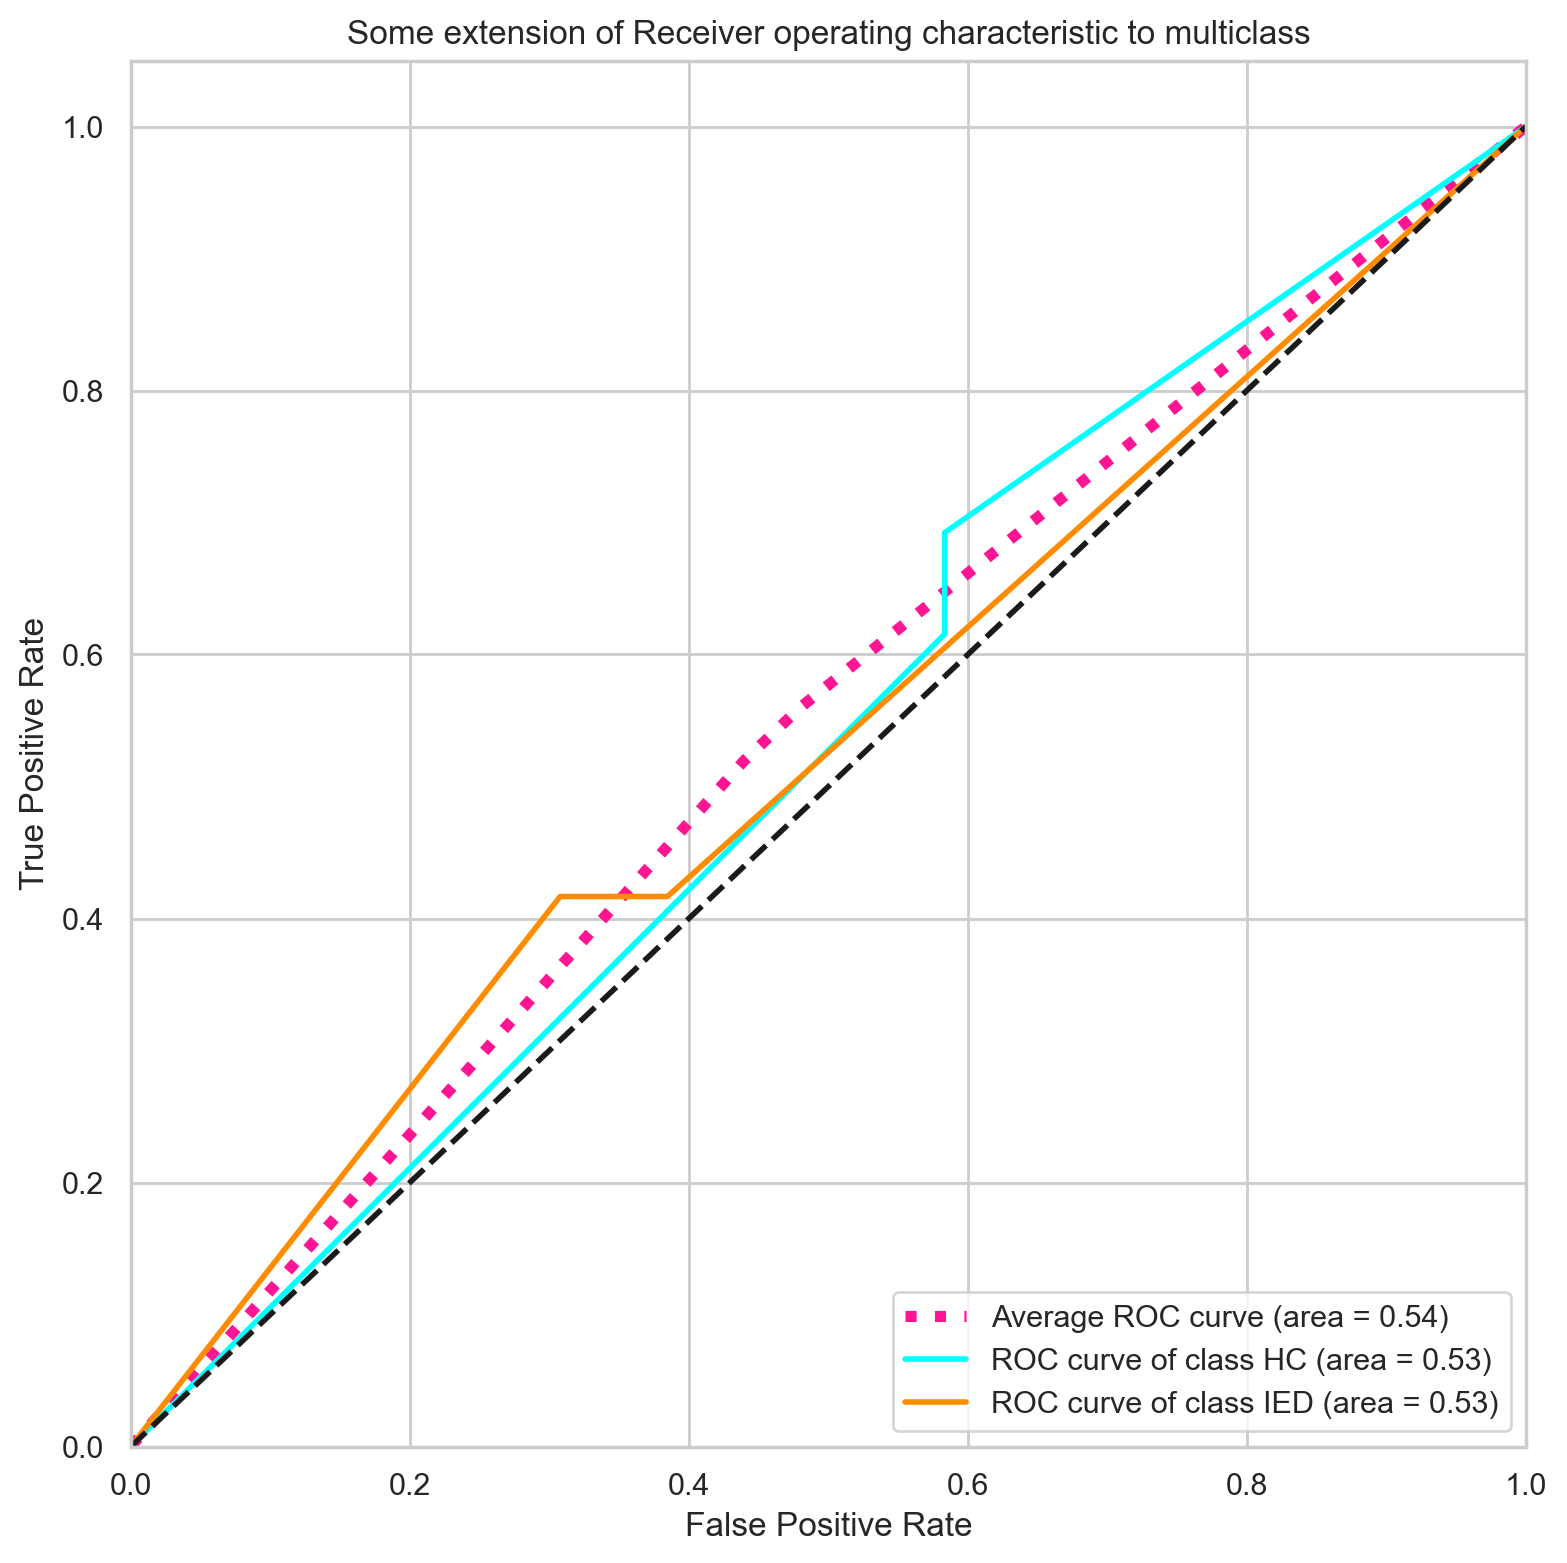

In [135]:
from itertools import cycle
lw = 2

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(trues_onehot[:, i], preds_prob_np[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(trues_onehot.ravel(), preds_prob_np.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= NUM_CLASSES

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(9,9), dpi=200)
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="Average ROC curve (area = {0:0.2f})".format(roc_auc["micro"]),
    color="deeppink",
    linestyle=":",
    linewidth=4,
)

colors = cycle(["aqua", "darkorange", "cornflowerblue"])
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=lw,
        label="ROC curve of class {0} (area = {1:0.2f})".format(LABEL_MAP[i], roc_auc[i]),
    )

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Some extension of Receiver operating characteristic to multiclass")
plt.legend(loc="lower right")
plt.show()

## Feature Isolated Analysis

In [136]:
import seaborn as sns
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt

custom_palette = ["#00712D", "#FF9100", "#D5ED9F", "#FFFBE6"]

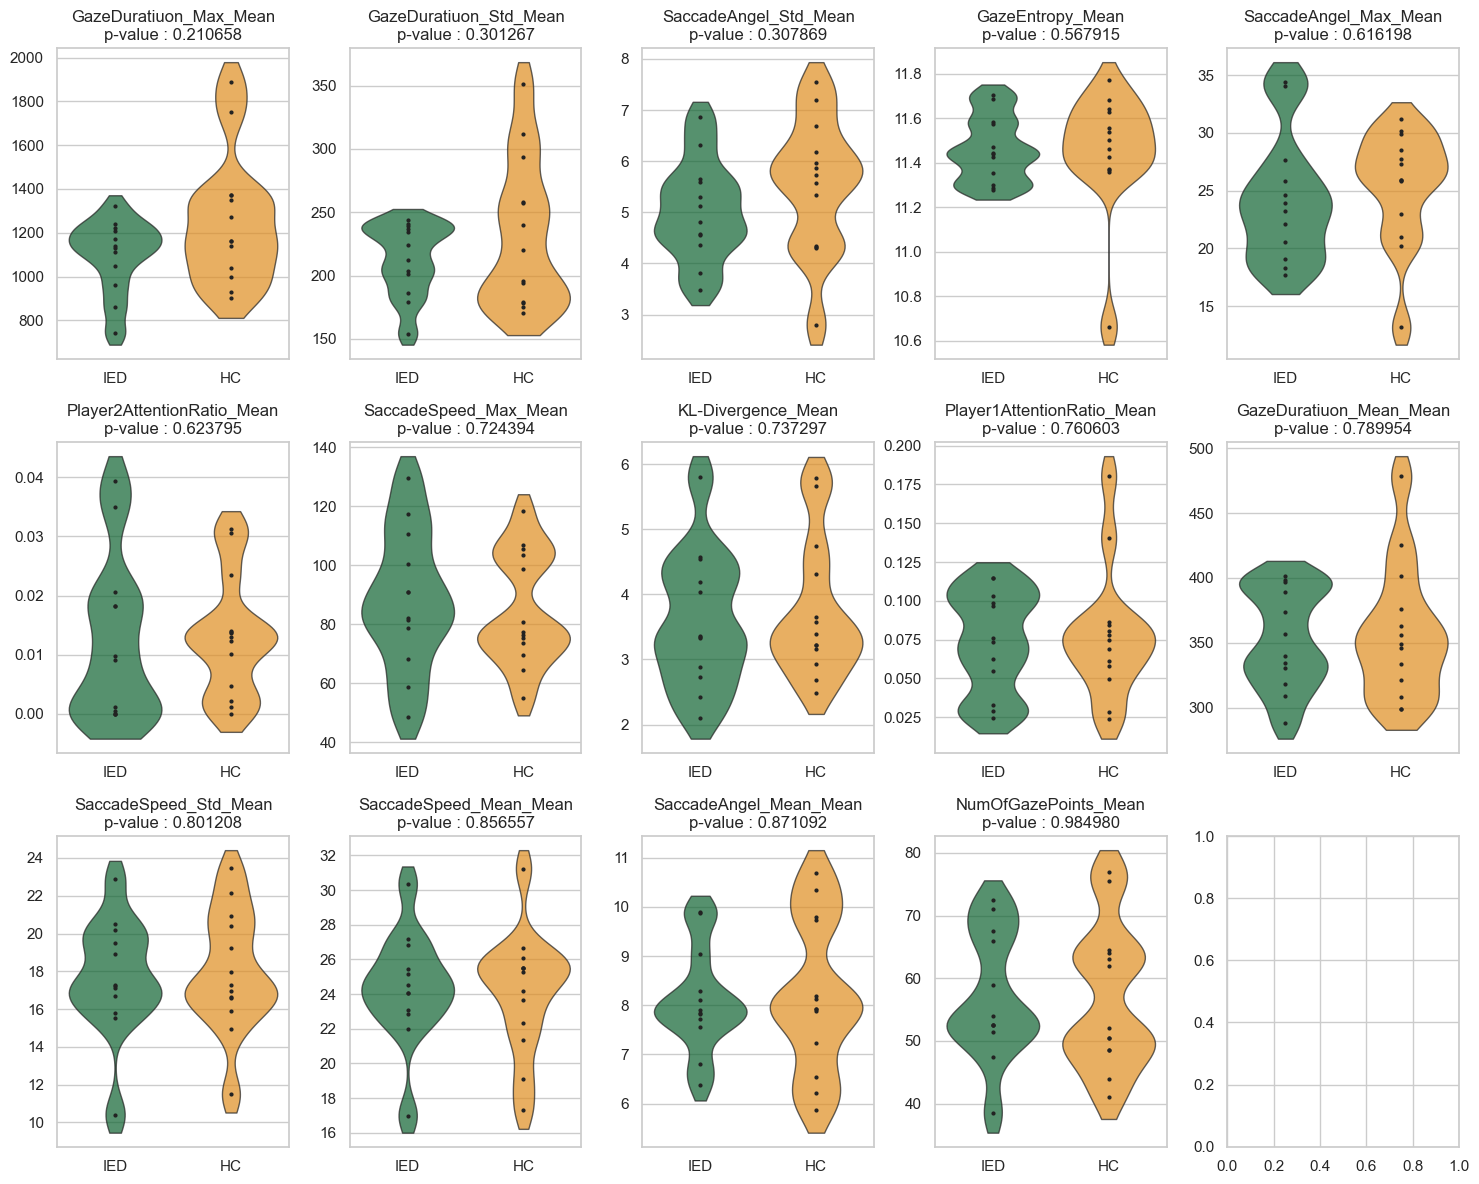

In [137]:
_ncols = 5
_nrows = (pt_res.shape[0]//_ncols) if (pt_res.shape[0]%_ncols)==0 else (pt_res.shape[0]//_ncols)+1

f, axs = plt.subplots(nrows=_nrows, ncols=_ncols, figsize=(3*_ncols, 4*_nrows))
for idx, (col, row) in enumerate(pt_res.iterrows()):
    if col=="diag" or col=="label": continue
    # col = "MatchRoundRatio_Mean"

    # Set up the matplotlib figure
    # Draw a violinplot with a narrower bandwidth than the default
    try:
        temp_ax = axs[idx//_ncols, idx%_ncols]
    except:
        temp_ax = axs[idx%_ncols]

    sns.violinplot(
            data=features_df.loc[:, [col, "diag"]], 
            palette=custom_palette,
            alpha=0.7,
            bw_adjust=.5, 
            cut=1, 
            linewidth=1, 
            x="diag", 
            y=col, 
            inner="point", 
            ax=temp_ax
        )
    
    temp_ax.set_xlabel("")
    temp_ax.set_ylabel("")
    temp_ax.set_title("{}\np-value : {:.6f}".format(col, row["p-value"]))
    # sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.savefig("output/sig_features_{}.png".format(sports), dpi=200)

In [138]:
ans = {}
parameters = {
        # "C": [1,0.9,0.8,0.7],
        # "kernel": ["linear", "rbf", "poly"]
        "kernel": ["linear"]
    }

for idx, (col, row) in enumerate(pt_res.iterrows()):
    if col=="diag" or col=="label": continue
    X = features_df[[col]]
    y = features_df['label']
    
    temp_d = {}
    svm = SVC()
    clf = GridSearchCV(svm, parameters, cv=5)
    clf.fit(X, y)
    temp_d["p-value"] = row["p-value"]
    # temp_d["C"] = clf.best_params_["C"]
    temp_d["kernel"] = clf.best_params_["kernel"]
    temp_d["MeanScore"] = clf.cv_results_["mean_test_score"]
    temp_d["BestScore"] = clf.best_score_


    ans[col] = temp_d

In [143]:
pd.DataFrame(ans).T

,p-value,kernel,MeanScore,BestScore
GazeDuratiuon_Max_Mean,0.210658,linear,[0.5599999999999999],0.56
GazeDuratiuon_Std_Mean,0.301267,linear,[0.48],0.48
SaccadeAngel_Std_Mean,0.307869,linear,[0.5599999999999999],0.56
GazeEntropy_Mean,0.567915,linear,[0.36000000000000004],0.36
SaccadeAngel_Max_Mean,0.616198,linear,[0.56],0.56
Player2AttentionRatio_Mean,0.623795,linear,[0.36],0.36
SaccadeSpeed_Max_Mean,0.724394,linear,[0.32],0.32
KL-Divergence_Mean,0.737297,linear,[0.4],0.4
Player1AttentionRatio_Mean,0.760603,linear,[0.36000000000000004],0.36
GazeDuratiuon_Mean_Mean,0.789954,linear,[0.31999999999999995],0.32


In [145]:
pd.DataFrame(ans).T.to_csv(f"output/{sports}.csv")

In [146]:
pd.DataFrame(ans).T.to_csv(f"{sports}.csv")

In [142]:
sports

'wangqiu'